# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# **Read the files**

In [2]:
books = pd.read_csv('Books.csv', encoding='latin-1')
users = pd.read_csv('Users.csv', encoding='latin-1')
ratings = pd.read_csv('Ratings.csv', encoding='latin-1')

# **Check shape of Dataframe**

In [3]:
print("Books:", books.shape)
print("Users:", users.shape)
print("Ratings:", ratings.shape)

Books: (271360, 8)
Users: (278858, 3)
Ratings: (1149780, 3)


# **View Top 5 rows of dataframe**

In [4]:
# Top 5 rows of books dataset
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
# Top 5 rows of users dataset
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
# Top 5 rows of ratings dataset
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


# **Check Column Names**

In [7]:
# List of column names of books Dataframe
books.columns

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')

In [8]:
# List of column names of users Dataframe
users.columns

Index(['User-ID', 'Location', 'Age'], dtype='object')

In [9]:
# List of column names of ratings Dataframe
ratings.columns

Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object')

# **Check Missing Values**

In [10]:
books.isnull().sum()

# Book-Author- 2 missing values
# Publisher- 2 missing values
# Image-URL-L 3 missing values

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


# **Fill Missing values**

In [11]:
books['Book-Author'].fillna('Unknown', inplace=True)
books['Publisher'].fillna('Unknown', inplace=True)
books['Image-URL-L'].fillna('', inplace=True)

# **Verify Missing Values are filled or not**

In [12]:
books.isnull().sum()
# Verified all the missing values are filled properly

,0
ISBN,0
Book-Title,0
Book-Author,0
Year-Of-Publication,0
Publisher,0
Image-URL-S,0
Image-URL-M,0
Image-URL-L,0


In [13]:
users.isnull().sum()
# Age- 110762 missing values

,0
User-ID,0
Location,0
Age,110762


In [14]:
users['Age'].describe()
# min = 0
# max = 244

,Age
count,168096.000000
mean,34.751434
std,14.428097
min,0.000000
25%,24.000000
50%,32.000000
75%,44.000000
max,244.000000


In [15]:
# Replace Invalid Ages
users.loc[(users['Age'] < 5) | (users['Age'] > 100), 'Age'] = np.nan

In [16]:
# Fill Missing Values
users['Age'].fillna(users['Age'].median(), inplace=True)

In [17]:
# Verify
users['Age'].describe()

# min ≈ 5+
# max ≈ ≤100
# no extreme values

,Age
count,278858.000000
mean,33.643385
std,10.630979
min,5.000000
25%,29.000000
50%,32.000000
75%,35.000000
max,100.000000


In [18]:
ratings.isnull().sum()
# No missing values are present

,0
User-ID,0
ISBN,0
Book-Rating,0


# **Check duplicates**

In [19]:
books.duplicated().sum()
users.duplicated().sum()
ratings.duplicated().sum()

# No duplicates found

np.int64(0)

# **Split Location**

In [20]:
# Split column
location_split = users['Location'].str.split(',', expand=True)

In [21]:
# Assign columns
users['City'] = location_split[0]
users['State'] = location_split[1]
users['Country'] = location_split[2]

In [22]:
# Clean Spaces
users['City'] = users['City'].str.strip()
users['State'] = users['State'].str.strip()
users['Country'] = users['Country'].str.strip()

In [23]:
# Check
users[['Location', 'City', 'State', 'Country']].head(20)

,Location,City,State,Country
0,"nyc, new york, usa",nyc,new york,usa
1,"stockton, california, usa",stockton,california,usa
2,"moscow, yukon territory, russia",moscow,yukon territory,russia
3,"porto, v.n.gaia, portugal",porto,v.n.gaia,portugal
4,"farnborough, hants, united kingdom",farnborough,hants,united kingdom
5,"santa monica, california, usa",santa monica,california,usa
6,"washington, dc, usa",washington,dc,usa
7,"timmins, ontario, canada",timmins,ontario,canada
8,"germantown, tennessee, usa",germantown,tennessee,usa
9,"albacete, wisconsin, spain",albacete,wisconsin,spain


# **Convert Age into Groups**

Child (0–12),
Teen (13–19),
Young Adult (20–35),
Adult (36–60),
Senior (60+)

In [24]:
# Apply Grouping
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

users['Age_Group'] = pd.cut(users['Age'], bins=bins, labels=labels)

In [25]:
# Check
users[['Age', 'Age_Group']].head()

,Age,Age_Group
0,32.0,Young Adult
1,18.0,Teen
2,32.0,Young Adult
3,17.0,Teen
4,32.0,Young Adult


In [26]:
# Count distribution
users['Age_Group'].value_counts()

,count
Age_Group,
Young Adult,191322
Adult,60752
Teen,18497
Senior,7703
Child,584


In [27]:
# Keep only required columns of book dataset
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Image-URL-M']]

In [28]:
books

,ISBN,Book-Title,Book-Author,Image-URL-M
0,0195153448,Classical Mythology,Mark P. O. Morford,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,http://images.amazon.com/images/P/0192126040.0...


In [29]:
# removed zero ratings because they represent implicit feedback and do not reflect actual user preferences
ratings = ratings[ratings['Book-Rating'] > 0]
ratings_with_books = ratings.merge(books, on='ISBN')

# **Active Users Filtering**

In [30]:
# Group by the book ratings by user id wise
user_counts = ratings_with_books.groupby('User-ID').count()['Book-Rating']

In [31]:
# sort the book ratings in descending order
user_counts.sort_values(ascending=False).head()

,Book-Rating
User-ID,
11676,6943
98391,5691
189835,1899
153662,1845
23902,1180


In [32]:
# filter active users by keeping only those who had given more than 50 ratings.
active_users = user_counts[user_counts > 50].index
ratings_with_books = ratings_with_books[ratings_with_books['User-ID'].isin(active_users)]

In [33]:
# Check shape
ratings_with_books.shape

(151924, 6)

Some users had very few interactions, so I filtered out inactive users and kept only users with more than 50 ratings to improve recommendation quality.

# **Popular Books Filtering**

In [34]:
# group by the book ratings by book title wise
book_counts = ratings_with_books.groupby('Book-Title').count()['Book-Rating']

In [35]:
# sort the book count in descending order
book_counts.sort_values(ascending=False).head()

,Book-Rating
Book-Title,
The Lovely Bones: A Novel,131
Harry Potter and the Chamber of Secrets (Book 2),117
Bridget Jones's Diary,116
Harry Potter and the Prisoner of Azkaban (Book 3),105
The Da Vinci Code,101


In [36]:
# Filtering
popular_books = book_counts[book_counts >= 50].index
final_df = ratings_with_books[ratings_with_books['Book-Title'].isin(popular_books)]

In [37]:
# Check final shape
final_df.shape

(4298, 6)

I selected books with a minimum number of ratings to ensure statistical reliability in similarity calculations.

# **Pivot Table**

In [38]:
pt = final_df.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')
pt.fillna(0, inplace=True)

In [39]:
pt

User-ID,254,638,1424,1733,2033,2110,2276,2766,2891,2977,...,273718,273979,274004,274061,274301,275970,276680,277427,278137,278188
Book-Title,,,,,,,,,,,,,,,,,,,,,
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,9.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Painted House,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Time to Kill,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Angels &amp; Demons,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
To Kill a Mockingbird,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
When the Wind Blows,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
pt.shape

(64, 931)

I created a user-item matrix using pivot table where rows represent books and columns represent users.

# **Visualization**

# **Ratings distribution**

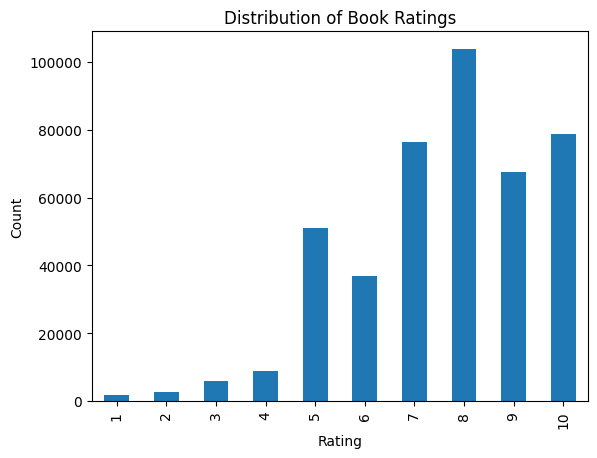

In [41]:
ratings['Book-Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The rating distribution is skewed toward higher values, with most ratings between 7 and 10 and a peak at 8. This indicates a positive bias where users tend to rate books they like. Low ratings are rare, which suggests limited negative feedback. This impacts the recommendation system by making it rely more on positive user interactions.

# **Top 10 most rated books**

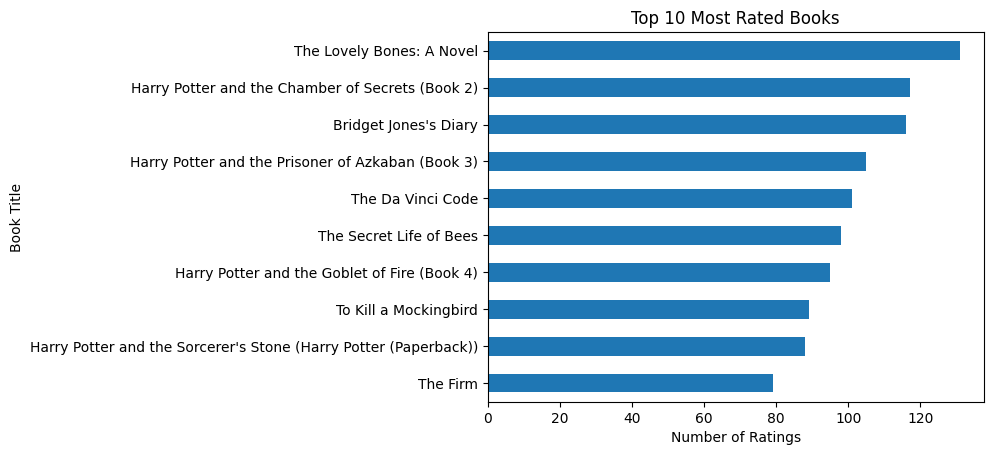

In [42]:
ratings_with_books['Book-Title'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Most Rated Books")
plt.xlabel("Number of Ratings")
plt.ylabel("Book Title")
plt.gca().invert_yaxis()
plt.show()

The graph shows the top 10 most rated books, indicating the most popular books in the dataset. ‘The Lovely Bones’ has the highest number of ratings, and multiple Harry Potter books appear, showing strong user engagement with that series. The rating counts are relatively close, indicating balanced popularity. These popular books are important for building a reliable recommendation system.

# **Top 10 authors**

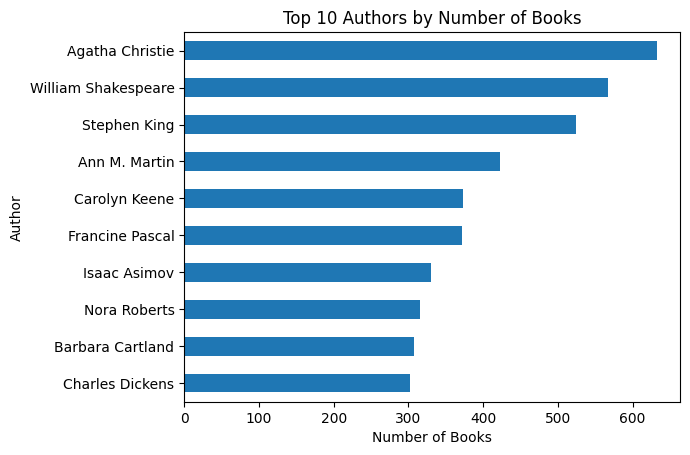

In [43]:
books['Book-Author'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.gca().invert_yaxis()
plt.show()

Agatha Christie has the highest number of books, followed by William Shakespeare and Stephen King. The dataset contains a mix of genres including mystery, horror, and classics. The distribution indicates that some authors dominate the dataset, which may introduce bias in the recommendation system toward more prolific authors.

# **Average Ratings Distribution**

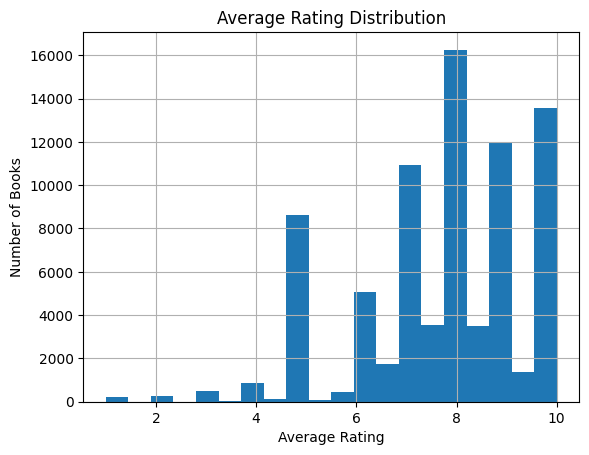

In [44]:
avg_rating = ratings_with_books.groupby('Book-Title')['Book-Rating'].mean()

avg_rating.hist(bins=20)
plt.title("Average Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.show()

The average rating distribution shows that most books have ratings between 7 and 10, with a peak around 8. This indicates a strong positive bias in the dataset, where users tend to rate books they like. Low-rated books are rare, which means the recommendation system will primarily rely on positive feedback.

# **Age Group Distribution**

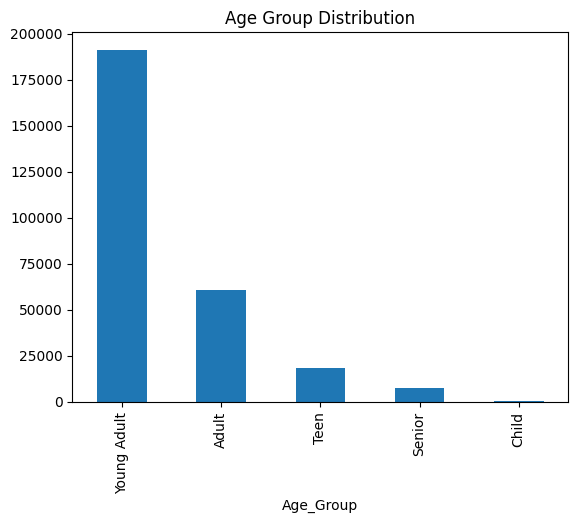

In [45]:
users['Age_Group'].value_counts().plot(kind='bar')
plt.title("Age Group Distribution")
plt.show()

The age distribution shows that most users are young adults, followed by adults, while teens, seniors, and children are underrepresented. This indicates that the dataset is skewed toward younger users, which may bias the recommendation system toward their preferences.